In [ ]:
!pip install -q \
langchain \
langchain-community \
langchain-openai \
langgraph \
chromadb \
pypdf \
tiktoken \
duckduckgo-search

# 1. Database loading

In [ ]:
import os
import uuid
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import START, StateGraph, END
from typing import TypedDict, List
from typing import Literal
from getpass import getpass
from IPython.display import Image, display


os.environ["OPENAI_API_KEY"] = getpass("Enter your key")
loader = PyPDFLoader("/content/orion_hub_manual .pdf")
documents = loader.load()

print(f"Number of pages: {len(documents)}")
print(documents[0].page_content[:500])

Enter your key··········
Number of pages: 1
ENTERPRISE TECHNICAL MANUAL & FAQ: ORION SMARTHUB X1 PRO GATEWAY
Product Engine: Orion Core Ecosystem Hardware Model: SmartHub-X1-PRO Firmware
Baseline: Stable Build v4.12.0 Document ID: TECH-REF-2026-REV2 1. HARDWARE
SPECIFICATIONS & INTERNAL CHIPSETS --------------------------------------------------------------------
-- The Orion SmartHub X1 Pro serves 


# 2. Build Vector Database

In [ ]:

text_splitter = RecursiveCharacterTextSplitter(

    chunk_size=500,
    chunk_overlap=100
)

chunks = text_splitter.split_documents(documents)

print("Number of Chunks:", len(chunks))

for i, chunk in enumerate(chunks[:2]):
    print("=" * 60)
    print(f"Chunk {i+1}")
    print(chunk.page_content[:500])
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small"
)
collection_name = f"orion_{uuid.uuid4().hex}"
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name=collection_name
)
query = "How do I factory reset the SmartHub?"

retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={
        "k": 5,
        "fetch_k": 10
    }
)
results = retriever.invoke(
    query
)

Number of Chunks: 13
Chunk 1
ENTERPRISE TECHNICAL MANUAL & FAQ: ORION SMARTHUB X1 PRO GATEWAY
Product Engine: Orion Core Ecosystem Hardware Model: SmartHub-X1-PRO Firmware
Baseline: Stable Build v4.12.0 Document ID: TECH-REF-2026-REV2 1. HARDWARE
SPECIFICATIONS & INTERNAL CHIPSETS --------------------------------------------------------------------
Chunk 2
-- The Orion SmartHub X1 Pro serves as a high-performance local bridge and supervisor node
for hybrid smart home fabrics. - Main Processor: Quad-core 1.8GHz ARM Cortex-A53 Compute
Unit - Neural Engine: Integrated 0.5 TOPS Edge-AI core for offline voice intent processing -
System Memory: 2GB DDR4 Non-ECC RAM - Storage Architecture: 16GB eMMC 5.1 Flash
partitions - Network Stack: Dual-Band Wi-Fi (2.4GHz / 5GHz 802.11ax), Gigabit Ethernet RJ-45,


# 3. Support Specialist Agent

In [ ]:

llm = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0
)
rewrite_prompt = ChatPromptTemplate.from_template("""
You are an expert Technical Support Specialist for the Orion SmartHub X1 Pro.

Your task is to rewrite customer questions into keyword-rich search queries for a vector database.

Instructions:
- Preserve the original intent.
- If the product name is missing, assume it is "Orion SmartHub X1 Pro".
- Replace vague words with technical terminology when appropriate.
- Include likely technical keywords that could appear in documentation.
- Do NOT answer the question.
- Return ONLY the rewritten search query.

Customer Question:
{question}
""")
query_rewriter = rewrite_prompt | llm
def rewrite_query(state):
    """
    Support Specialist Agent:
    Rewrites the user's query into an optimized search query.
    """

    response = query_rewriter.invoke(
        {"question": state["original_query"]}
    )

    return {
        "optimized_query": response.content
    }
sample_state = {
    "original_query": "My hub keeps showing red light."
}

result = rewrite_query(sample_state)


In [ ]:
def retrieve_documents(state):
    results = retriever.invoke(
        state["optimized_query"]
    )

    return {
        "documents": results
    }

# 4. QA Engineer Agent

In [ ]:
class RelevanceGrade(BaseModel):
    relevance_score: Literal["yes", "no"] = Field(
        description="Whether the retrieved documents are relevant."
    )
structured_llm = llm.with_structured_output(RelevanceGrade)
grade_prompt = ChatPromptTemplate.from_template("""
You are a QA Engineer responsible for validating document retrieval.

Your task is NOT to answer the user's question.

Your ONLY task is to determine whether the retrieved documents are relevant enough to continue.

Evaluation Rules:

- Return "yes" if one or more retrieved documents discuss the same product, feature, error code, LED status, troubleshooting step, or topic as the user's question.
- Return "yes" even if the documents only partially answer the question.
- Return "no" ONLY if the retrieved documents are completely unrelated.

User Question:
{question}

Retrieved Documents:
{documents}
""")
document_grader = grade_prompt | structured_llm
def grade_documents(state):
    """
    QA Engineer Agent

    Checks whether the retrieved documents
    are relevant enough to answer the question.
    """

    documents = "\n\n".join(
        [doc.page_content for doc in state["documents"]]
    )

    result = document_grader.invoke(
        {
            "question": state["optimized_query"],
            "documents": documents,
        }
    )

    return {
        "relevance_score": result.relevance_score
    }
sample_state = {
    "optimized_query": "How do I factory reset the SmartHub?",
    "documents": results
}

In [ ]:
state = {
    "original_query": "My hub keeps showing red light."
}

state.update(rewrite_query(state))
state.update(retrieve_documents(state))
state.update(grade_documents(state))

print(state.keys())
print(state["relevance_score"])

dict_keys(['original_query', 'optimized_query', 'documents', 'relevance_score'])
yes


In [ ]:
!pip install -q duckduckgo-search ddgs

In [ ]:
search_tool = DuckDuckGoSearchResults(
    num_results=3
)

In [ ]:
def web_search(state):
    """
    Perform a web search and append the results
    as a Document object.
    """

    web_results = search_tool.invoke(state["optimized_query"])

    web_document = Document(
        page_content=str(web_results),
        metadata={"source": "web_search"}
    )

    updated_documents = state.get("documents", []).copy()
    updated_documents.append(web_document)

    return {
        "documents": updated_documents
    }

# 5. Build the Generator Agent

In [ ]:
generate_prompt = ChatPromptTemplate.from_template("""
You are an expert Technical Support Engineer.

Answer the user's question using ONLY the information contained in the provided documents.

Instructions:
- Do NOT invent information.
- Do NOT make assumptions.
- If the documents do not contain enough information, clearly state that.
- Every statement in your answer must be directly supported by the retrieved documents.
   Do not infer troubleshooting steps.
   Do not invent recommendations.
- Use numbered steps whenever appropriate.

User Question:
{question}

Retrieved Documents:
{documents}
""")
generator = generate_prompt | llm

In [ ]:
def generate_answer(state):
    """
    Support Specialist Agent

    Generates the final technical response
    using the retrieved documents.
    """

    documents = "\n\n".join(
        [doc.page_content for doc in state["documents"]]
    )

    response = generator.invoke(
        {
            "question": state["original_query"],
            "documents": documents,
        }
    )

    return {
        "generation": response.content
    }

# 6. Build the Hallucination Judge (QA Agent)

In [ ]:
class HallucinationGrade(BaseModel):

    hallucination_check: Literal["passed", "failed"] = Field(
        description="Whether the generated answer is grounded in the provided documents."
    )

hallucination_llm = llm.with_structured_output(
    HallucinationGrade
)
hallucination_prompt = ChatPromptTemplate.from_template("""
You are a QA Engineer responsible for checking whether an AI-generated answer is supported by the provided documents.

Instructions:

- Compare the generated answer with the retrieved documents.
- Return "passed" if every important claim is supported by the documents.
- Return "failed" if the answer includes unsupported information or hallucinations.
- Do NOT judge writing quality.
- Judge ONLY factual grounding.

Retrieved Documents:
{documents}

Generated Answer:
{generation}
""")
hallucination_checker = (
    hallucination_prompt
    | hallucination_llm
)
def hallucination_check(state):
    """
    QA Engineer Agent

    Checks whether the generated answer
    is grounded in the retrieved documents.
    """

    documents = "\n\n".join(
        [doc.page_content for doc in state["documents"]]
    )

    result = hallucination_checker.invoke(
        {
            "documents": documents,
            "generation": state["generation"],
        }
    )

    return {
        "hallucination_check": result.hallucination_check
    }
def route_after_grading(state):
    """
    Decide whether to generate an answer
    or perform a web search.
    """

    if state["relevance_score"] == "yes":
        return "generate"

    return "web"
def route_after_hallucination(state):

    if state["hallucination_check"] == "passed":
        return "end"

    if state["loop_count"] >= 2:
        return "end"

    return "retry"
def increment_loop(state):
    """
    Increment retry counter.
    """

    return {
        "loop_count": state.get("loop_count", 0) + 1
    }

# 7. Connect the Nodes (LangGraph Routing)

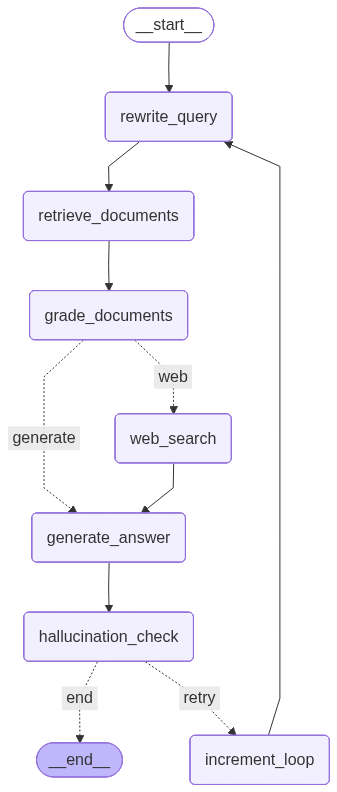

The flashing red light on your hub indicates a critical kernel error has been detected.

According to the hardware LED diagnostic light matrix for the Orion SmartHub X1 Pro:

- **Flashing Crimson Red** means a critical kernel error is present.

To address this issue, please follow these steps:

1. Inspect the hardware for any physical damage or integrity issues.
2. Ensure the OEM USB-C power supply is properly connected to the hub and plugged into a power outlet.
3. Observe the LED status light for any changes.
4. If the flashing red persists, you may need to perform a system reset or re-provision the device, but the provided documents do not include specific reset instructions for this error.

If the problem continues, please consult the official support resources or contact technical support for further assistance, as the documents do not provide additional troubleshooting steps for the flashing red light condition.


In [ ]:
# Define GraphState
class GraphState(TypedDict):
    original_query: str
    optimized_query: str
    documents: List[Document]
    generation: str
    relevance_score: str
    hallucination_check: str
    loop_count: int

# Initialize builder
builder = StateGraph(GraphState)

# Add nodes
builder.add_node(
    "rewrite_query",
    rewrite_query
)
builder.add_node(
    "retrieve_documents",
    retrieve_documents
)
builder.add_node(
    "grade_documents",
    grade_documents
)
builder.add_node(
    "web_search",
    web_search
)
builder.add_node(
    "generate_answer",
    generate_answer
)
builder.add_node(
    "hallucination_check",
    hallucination_check
)
builder.add_node(
    "increment_loop",
    increment_loop
)

# Add edges
builder.add_edge(
    START,
    "rewrite_query"
)
builder.add_edge(
    "rewrite_query",
    "retrieve_documents"
)
builder.add_edge(
    "retrieve_documents",
    "grade_documents"
)
builder.add_conditional_edges(
    "grade_documents",
    route_after_grading,
    {
        "generate": "generate_answer",
        "web": "web_search",
    }
)
builder.add_edge(
    "web_search",
    "generate_answer"
)
builder.add_edge(
    "generate_answer",
    "hallucination_check"
)
builder.add_conditional_edges(
    "hallucination_check",
    route_after_hallucination,
    {
        "end": END,
        "retry": "increment_loop"
    }
)
builder.add_edge(
    "increment_loop",
    "rewrite_query"
)

def build_graph():
    return builder.compile()

graph = build_graph()
display(Image(graph.get_graph().draw_mermaid_png()))
initial_state = {
    "original_query": "My hub keeps showing a flashing red light.",
    "optimized_query": "",
    "documents": [],
    "generation": "",
    "relevance_score": "",
    "hallucination_check": "",
    "loop_count": 0
}

result = graph.invoke(initial_state)
print(result["generation"])


# Conclusion

This notebook demonstrates an Agentic RAG workflow using:

- Query Rewriter
- Vector Retrieval
- QA Document Grader
- Web Search Fallback
- Response Generator
- Hallucination Checker
- LangGraph orchestration

The workflow successfully retrieves relevant documentation and generates grounded technical responses.